The equation being solved models a chemical reaction with both quick, transient dynamics, and equilibrium condition which is over a long period of time. The difference in time frame between these make the problem stiff. 

The equation is defined by C'(t) = -k(C - C_eq(t)) where C_eq(t) = 1 + 0.1sin(0.1t)). You will notice that the rate of reaction (k) is very large while C_eq has small coefficients so changes over a very long period of time. The large difference in the magnitude of these coefficients makes the problem stiff. The stiffness ratio is 10,000. The basic implicit solver is Eulers backwards with the newton-raphson iteration. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters 
k = 1e4
C_eq = lambda t: 1.0 + 0.1*np.sin(0.1*t)

def f(t, C):
    return -k*(C - C_eq(t))

# Analytical solution
t_ref = np.linspace(0, 50.0, 1001)
C_ref = odeint(lambda C, t: -k*(C - C_eq(t)), 0.0, t_ref, atol=1e-12, rtol=1e-12).flatten()

# Backward Euler residual
def g_func(y_guess, y_n, t_next, h):
    return y_guess - y_n - h*f(t_next, y_guess)

def g_prime_func(h):
    return 1 + h*k

In [2]:
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_prime_func(h)
        delta = -g / g_prime

        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)

        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))

            if g_new < g_current: # Sufficient decrease
                break

            alpha = alpha / 2.0

            if alpha < alpha_min:
                return y_guess, k, False

        y_guess = y_new

    return y_guess, max_iter, False

def nr_solver(y_n, t_next, h):
    return damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func)

For updating the guess, Newton-Raphson (NR) normally uses the equation y_new = y_guess - g(y_guess)/g'(y_guess). This works fine if the initial guess is close to the solution but if the initial guess is bad or the step size is too large, the method could fail. In order to fix this issue, damping was added. The damped NR iteration uses the equation y_new = y_guess + alpha * delta where delta is g(y_guess)/g'(y_guess) to update the guess. The code starts with an alpha of 1 and then cuts it in half if the residual doesn't decrease (line search). The point of the line search is to only use NR steps that decrease the residual. 

In [3]:
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    
    # Single step of size h
    y_full, iters_full, s1 = nr_solver(y_n, t_n + h, h)

    # Two half-steps of size h/2
    y_half_1, iters_1, s2 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2, s3 = nr_solver(y_half_1, t_n + h, h/2)

    # Error estimate
    error = abs(y_half - y_full)

    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2

    success = s1 and s2 and s3

    return y_full, y_half, error, total_iters, success

def adjust_step_size(h_current, error, tol, old_error, safety=0.9, h_min=1e-8, h_max=10.0):
   
    # Use PI controller to compute new step size
    error = max(error, 1e-14)
    old_error = max(old_error, 1e-14)

    h_new = h_current * (tol/error)**0.5 * (old_error/error)**0.2

    # Apply safety factor
    h_new = safety * h_new

    # Enforce bounds
    h_new = max(h_min, min(h_max, h_new))

    # Don't change h too aggressively
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new

def adaptive_step(y_n, t_n, h, tol, nr_solver, old_error):

    # Try the step with error estimation
    y_full, y_half, error, iters, success = estimate_error_step_doubling(y_n, t_n, h, nr_solver)

    # Compute new step size suggestion
    h_new = adjust_step_size(h, error, tol, old_error)

    # Accept or reject?
    if error < tol and success:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters, error
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters, error

In [4]:
def adaptive_implicit_euler(y0, t0, t_final, h0, tol=1e-4):
    # Initialize
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []
    attempt_t = []
    attempt_h = []
    attempt_accept = []
    old_error = tol

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'function_evals': 0,
        'nr_iterations': 0,
    }
    

    while t[-1] < t_final - 1e-10:
        if t[-1] + h > t_final:
            h = t_final - t[-1]

        y_next, h_used, h_new, accepted, iters, error = adaptive_step(y[-1], t[-1], h, tol, nr_solver, old_error)

        attempt_t.append(t[-1])
        attempt_h.append(h)
        attempt_accept.append(accepted)

        stats['nr_iterations'] += iters
        stats['function_evals'] += 2*iters

        if accepted:
            t.append(t[-1] + h_used)
            y.append(y_next)
            h_history.append(h_used)
            error_history.append(error)
            stats['accepted_steps'] += 1
            old_error = error
            h = h_new
            
        else:
            stats['rejected_steps'] += 1
            h = h_new

    return (np.array(t), np.array(y), np.array(h_history), np.array(error_history), np.array(attempt_t), np.array(attempt_h), np.array(attempt_accept), stats)

def euler_backward_fixed(y0, t0, t_final, h):
    t = [t0]
    y = [y0]
    total_iters = 0

    while t[-1] < t_final - 1e-10:
        h_use = h

        if t[-1] + h_use > t_final:
            h_use = t_final - t[-1]

        y_next, iters, success = nr_solver(y[-1], t[-1] + h_use, h_use)

        t.append(t[-1] + h_use)
        y.append(y_next)
        total_iters += iters

    return np.array(t), np.array(y), total_iters, 2*total_iters

In [5]:
def g_2(y, y_n, h):
    return y - y_n + h*(np.exp(np.clip(y, -50, 50)) - 10.0)

def g_2_prime(y, h):
    return 1.0 + h*np.exp(np.clip(y, -50, 50))

def basic_newton_raphson(y_n, h, tol=1e-8, max_iter=20):
    y_guess = y_n

    for k in range(max_iter):
        g = g_2(y_guess, y_n, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_2_prime(y_guess, h)
        y_guess = y_guess - g/g_prime

        if abs(y_guess) > 50:
            return y_guess, k + 1, False

    return y_guess, max_iter, False

def damped_newton_raphson_test(y_n, h, tol=1e-8, max_iter=20):
    y_guess = y_n

    for k in range(max_iter):
        g = g_2(y_guess, y_n, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_2_prime(y_guess, h)
        delta = -g/g_prime

        alpha = 1.0
        g_current = abs(g)

        for _ in range(10):
            y_new = y_guess + alpha*delta
            g_new = abs(g_2(y_new, y_n, h))

            if g_new < g_current:
                break

            alpha = alpha/2.0

        y_guess = y_new

    return y_guess, max_iter, False

In [6]:
# Dampeed vs undamped conversion comparison at large h
print("Testing undamped NR with h = 10.0:")
try:
    y_undamped, iters_undamped, success_undamped = basic_newton_raphson(-10.0, 10.0)
    print(f"Converged: {success_undamped}, iterations: {iters_undamped}")
except:
    print("Failed to converge!")

print("\nTesting damped NR with h = 10.0:")
y_damped, iters_damped, success_damped = damped_newton_raphson_test(-10.0, 10.0)
print(f"Converged: {success_damped}, iterations: {iters_damped}")
print()


Testing undamped NR with h = 10.0:
Converged: False, iterations: 1

Testing damped NR with h = 10.0:
Converged: True, iterations: 5



Here we compared the undamped NR with the damped NR by testing to see whether the method converges with a bad initial guess of -10 and a large step size of 10. We can see that the undamped NR fails to converge at 1 iteration while in 5 iterations the damped NR is able to converge. This shows the main benefit of damping, it allows for convergence even with a bad initial guess and large step size. 

In [7]:
# Adaptive vs fixed step size
t_adapt, y_adapt, h_hist, error_history, attempt_t, attempt_h, attempt_accept, stats = adaptive_implicit_euler(0.0, 0.0, 50.0, 0.1, tol=1e-4)

t_fixed, y_fixed, fixed_iters, fixed_evals = euler_backward_fixed(0.0, 0.0, 50.0, 0.01)

print("Adaptive solver:")
print("Accepted steps:", stats['accepted_steps'])
print("Rejected steps:", stats['rejected_steps'])
print("Total NR iterations:", stats['nr_iterations'])
print("Function evaluations:", stats['function_evals'])
print()

print("Performance comparison")
print("Fixed h=0.01 Steps = ", len(t_fixed)-1, " Function evals = ", fixed_evals)
print("Adaptive PI Steps = ", stats['accepted_steps'], " Function evals = ", stats['function_evals'])
print()

# Robustness testing for adaptive solver with large initial h and tight tolerance
t_big, y_big, h_big, e_big, at_big, ah_big, aa_big, st_big = adaptive_implicit_euler(0.0, 0.0, 50.0, 1.0, tol=1e-4)

t_tight, y_tight, h_tight, e_tight, at_tight, ah_tight, aa_tight, st_tight = adaptive_implicit_euler(0.0, 0.0, 50.0, 0.1, tol=1e-8)

# Work-precision diagram data
tol_values = [1e-3, 1e-4, 1e-5]
work_adapt = []
error_adapt = []

for tol in tol_values:
    t_a, y_a, h_a, e_a, at_a, ah_a, aa_a, st_a = adaptive_implicit_euler(0.0, 0.0, 50.0, 0.1, tol=tol)
    work_adapt.append(st_a['function_evals'])
    error_adapt.append(abs(y_a[-1] - np.interp(t_a[-1], t_ref, C_ref)))

h_values = [10.0, 1.0, 0.1, 0.01]
work_fixed = []
error_fixed = []

for h in h_values:
    t_f, y_f, it_f, ev_f = euler_backward_fixed(0.0, 0.0, 50.0, h)
    work_fixed.append(ev_f)
    error_fixed.append(abs(y_f[-1] - np.interp(t_f[-1], t_ref, C_ref)))

Adaptive solver:
Accepted steps: 123
Rejected steps: 8
Total NR iterations: 393
Function evaluations: 786

Performance comparison
Fixed h=0.01 Steps =  5000  Function evals =  10000
Adaptive PI Steps =  123  Function evals =  786



Adaptive step size control was implemented using a step doubling error estimation. It works by comparing one larger step to two smaller half steps to see which is more accurate. If the half steps have a smaller error, then the code uses that, and if the larger stepp has a smaller error then that is used instead. A PI controller was also implemented to adjust the step size. The PI controller chooses the next step size via a calculation using the current error and previous error. A safety factor is also applied in order to ensure that the step size does not change too drastically. If the error is less than the tolerance then the step is used and if not then the step is rejected and a smaller h value is tried.

The code records the number of accepted and rejected steps as well as the total NR iterations and total function evaluations. 

The adaptive PI method was compared to the fixed step Eulers backward using a step size of 0.01. The adaptive PI method had 123 accepted steps and 8 rejected steps making a total of 131 steps. The function was evaluated a total of 786 times. Comparing this to the fixed step size, 5000 steps were needed which took 10000 function evaluations. This is a massive improvement in cost for the adaptive PI method. The adaptive PI method is able to be so much more efficient because it uses small steps at the beggining when the solution is exhibiting its rapid, transient behavior and then it uses much larger step sizes later on while the solution is in its equilibrium state. The fixed step method does not have this advantage as it must use a step size of 0.01 the entire time in order to properly model the rapid dynamics part of the solution. 

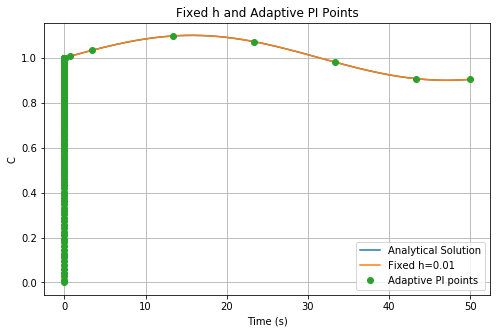

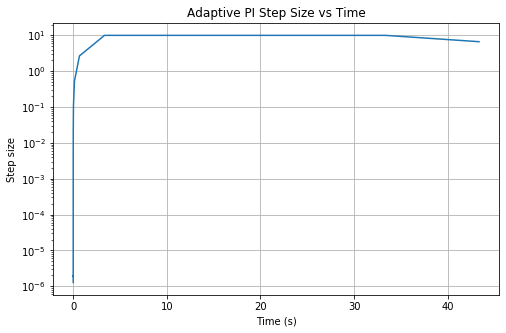

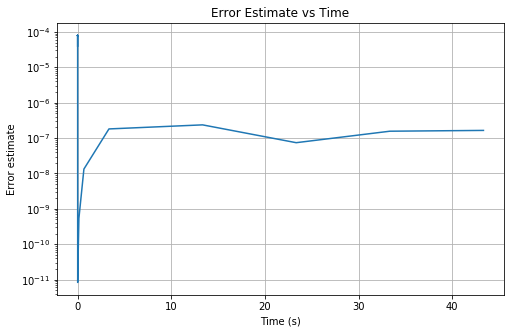

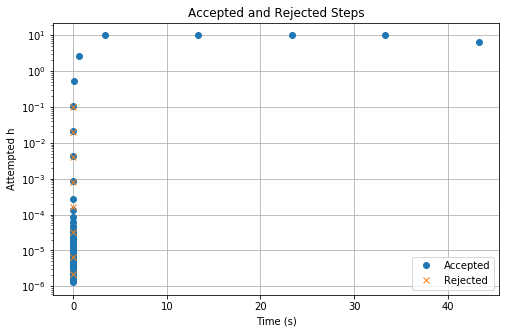

In [8]:
# Solution with adaptive time points
plt.figure(figsize=(8,5))
plt.plot(t_ref, C_ref, label="Analytical Solution")
plt.plot(t_fixed, y_fixed, label="Fixed h=0.01")
plt.plot(t_adapt, y_adapt, "o", label="Adaptive PI points")
plt.xlabel("Time (s)")
plt.ylabel("C")
plt.title("Fixed h and Adaptive PI Points")
plt.legend()
plt.grid(True)

# Step size h vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], h_hist)
plt.xlabel("Time (s)")
plt.ylabel("Step size")
plt.title("Adaptive PI Step Size vs Time")
plt.grid(True)

# Error estimate vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], error_history, label="Error estimate")
plt.xlabel("Time (s)")
plt.ylabel("Error estimate")
plt.title("Error Estimate vs Time")
plt.grid(True)

# Accepted and rejected steps
accepted = attempt_accept == True
rejected = attempt_accept == False

plt.figure(figsize=(8,5))
plt.semilogy(attempt_t[accepted], attempt_h[accepted], "o", label="Accepted")
plt.semilogy(attempt_t[rejected], attempt_h[rejected], "x", label="Rejected")
plt.xlabel("Time (s)")
plt.ylabel("Attempted h")
plt.title("Accepted and Rejected Steps")
plt.legend()
plt.grid(True)

As we can see on the fixed vs adaptive PI solution plot, both solutions match the analytical solution very closely; however, from around t = 2 to t = 50 the adaptive PI step size increases drastically as the accuracy is no longer needed. The fixed solution does not do this. 

On the plot showing the adaptive PI step size vs time, we can see that the step size increases rapidly as time increases. It starts very small around 10**-6 and then rapidly increases to around 10. This allows for it to have an even smaller step size than the fixed step size solution while the reaction is changing quickly, in order to have increased accuracy, and then a much larger step size for the equilibrium condition. 

For the error estimate vs time for the adaptive PI solution, we can see that the error estimate remains very low around 10**-7 the entire time.

When looking at the accepted and rejected steps, we can see that the rejected steps are at the beggining of the time period and mostly concentrated around when the h value is changing the most rapidly. This is because the h value is too large as the model is trying to change the h too aggressively as the conditions of the equation rapidly change. 

| Criteria | Fixed Step | Adaptive PI |
|:--------:|:--------:|:--------:|
|  Total steps   |  5000   |  131 |
|  Function Evaluations  |  10000   |  786   |
|  Accuracy for equillibrium behavior  |  high   |  high   |
|  Accuracy for transient behavior   |  high   |  high   |


Robustness testing for h0 = 1 and tol = 1e-8
Large initial h accepted steps: 8
Large initial h rejected steps: 0
Tight tolerance accepted steps: 11219
Tight tolerance rejected steps: 15


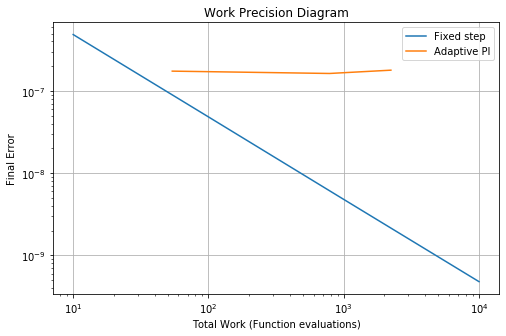

In [9]:
print("Robustness testing for h0 = 1 and tol = 1e-8")
print("Large initial h accepted steps:", st_big['accepted_steps'])
print("Large initial h rejected steps:", st_big['rejected_steps'])
print("Tight tolerance accepted steps:", st_tight['accepted_steps'])
print("Tight tolerance rejected steps:", st_tight['rejected_steps'])

# Work-precision diagram
plt.figure(figsize=(8,5))
plt.loglog(work_fixed, error_fixed, label="Fixed step")
plt.loglog(work_adapt, error_adapt, label="Adaptive PI")
plt.xlabel("Total Work (Function evaluations)")
plt.ylabel("Final Error")
plt.title("Work Precision Diagram")
plt.legend()
plt.grid(True)

plt.show()

Two robustness tests were performed. The first test used a large initial step size of 1 and a tolerance of 1e-4 and the second test used a small tolerance of 1e-8 with an intial step size of 0.1. For the first test the solver had 8 accepted steps and no rejected steps which shows that the solver can handle a large initial step size without crashing.

For the second test, there were 11219 accepted steps and 15 rejected steps. Due to the much lower tolerance, many more steps were required as the local error was required to be much much smaller. Even though the computational cost of the low tolerance is much higher, the solver is still able to handle it. The solver managed the h value in order to handle the poor initial conditions and tight tolerance very gracefully. 

The work precision diagram shows that the fixed step size's final error is linearly proportional to the total number of function evaluations. This is in contrast to the adaptive PI solvers final error which remained constant despite the increase in function evaluations. As the tolerance decreases, the total amount of function evaluations must increase which causes a decrease in the final error for the fixed step method. The final error for the adaptive PI method remains the same as it keeps the h value as high as possible to keep the solution within the tolerance, this causes a final error which is larger than the fixed step solution as the fixed step solution must use a very small step size around t=50 resulting in a very small error. 

In conclusion, damping is necessary when the initial guess is poor or if the residual is not linear. When the initial guess is close to the actual solution, damping is not needed as the residual is linear for the chemical reaction ODE. 

Adaptive sep sizes are worth the complexity when the solution is changing very rapidly in one part of the domain but slowly in the other part. Adaptive step sizes are able to optimize for this situation by keeping the step size very low while the solution is changing rapidly and increasing the step size when the accuracy is less nessary as the solution is changing more slowly.

Lessons learned were that the adaptive PI method is more efficient than the fixed step method for this stiff ODE. Damping also allows for more robustness to tighter tolerances and poor initial guesses. 